1) markvlovitz
2) black letterman
3) risk parity (erc, naive, hierachy)
Add naive + erc

In [1]:
from helper import get_matrices, get_ticker_expected, plot_efficient_frontier, get_market_caps, get_black_litterman, get_full_portfolio_df
from helper import run_hrp_optimization, run_cvar_optimization, get_returns
from finbert import ai_bl_params
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


/Users/sjegoh/Documents/GitHub/NUSSIF/Portfolio-Optimizer/venv_optimizer/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-08 21:57:41.930 No runtime found, using MemoryCacheStorageManager


In [2]:
basket = [
    "XOM",   # Energy: The most valuable company in the world in 2005
    "GE",    # Industrials: The gold standard of diversified conglomerates
    "MSFT",  # Tech: Dominant but viewed as a "stagnant" value play in 2005
    "C",     # Financials: Citigroup was a massive institutional staple
    "WFC",   # Financials: Wells Fargo was the "safe" regional banking play
    "PFE",   # Health Care: Pfizer was the dominant pharma name
    "KO",    # Staples: Coca-Cola, a classic "Sleep-at-Night" defensive
    "INTC",  # Tech: Intel was the undisputed king of semiconductors
    "WMT",   # Discretionary: Walmart was the retail world-beater
    "AIG",   # Financials: Considered "Too Big to Fail" before 2008
    "IBM",   # Tech: The bedrock of enterprise IT
    "TLT"    # Fixed Income: 20-Year Treasuries for diversification
]
start_date = "2024-01-01"


In [3]:
cv, _ = get_matrices(basket, start_date = start_date)


In [4]:
stats = get_ticker_expected(basket, start_date = start_date)
stats


,Expected Return,Volatility
XOM,0.180411,0.223322
GE,0.539903,0.309560
MSFT,0.045205,0.237154
C,0.322458,0.301367
WFC,0.225982,0.291317
PFE,-0.043681,0.246691
KO,0.116976,0.156564
INTC,-0.044438,0.605648
WMT,0.391433,0.221291
AIG,0.062012,0.233251


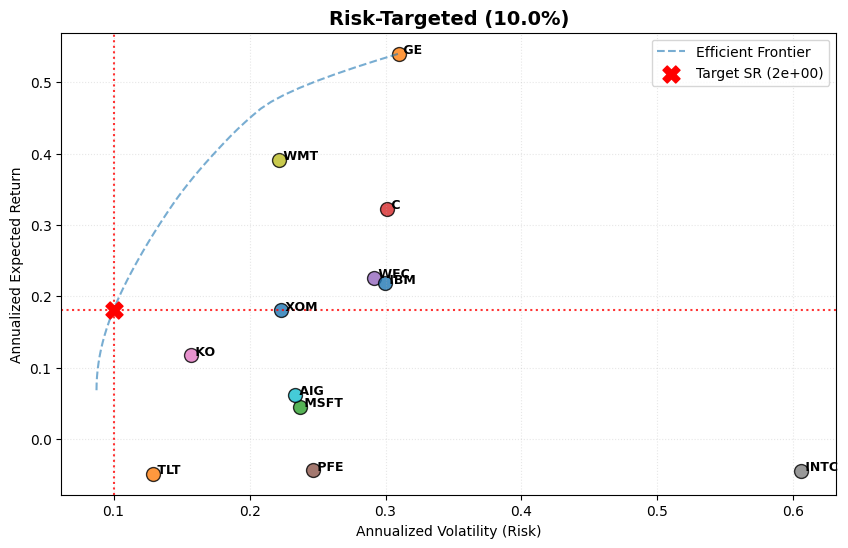

In [34]:
fig, weights = plot_efficient_frontier(stats, cv, basket, target_vol = 0.1)
plt.show()


In [6]:
weights


XOM     1.303484e-01
GE      3.134716e-01
MSFT    0.000000e+00
C       1.402373e-02
WFC     0.000000e+00
PFE     2.315807e-17
KO      9.172777e-02
INTC    1.191587e-15
WMT     4.394527e-01
AIG     0.000000e+00
IBM     1.097579e-02
TLT     0.000000e+00
Name: Optimal weights, dtype: float64

# Black Litterman
Need additional expected mu, conviction 

In [7]:
views_dict, conf_dict = ai_bl_params(basket)
market_caps = get_market_caps(basket)


2026-03-08 21:57:50.464 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 47485.36it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 21:57:53.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 64052.20it/s]
BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-fls
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from differe

In [8]:
final_views = {}
for ticker in basket:
    m_ret = stats["Expected Return"][ticker]
    n_ret = views_dict[ticker]
    
    combined = (m_ret + n_ret)
    final_views[ticker] = combined


In [9]:
market_caps


XOM     6.300563e+11
GE      3.388822e+11
MSFT    3.036785e+12
C       1.863550e+11
WFC     2.481468e+11
PFE     1.538135e+11
KO      3.313277e+11
INTC    2.168907e+11
WMT     9.867067e+11
AIG     4.223798e+10
IBM     2.428102e+11
TLT     4.435384e+10
Name: Market_Cap, dtype: float64

In [10]:
final_views


{'XOM': np.float64(0.19339962560795798),
 'GE': np.float64(0.5617754258567756),
 'MSFT': np.float64(0.05569357313350284),
 'C': np.float64(0.3409299053831237),
 'WFC': np.float64(0.23531425809253176),
 'PFE': np.float64(0.026937837312377207),
 'KO': np.float64(0.12186237872001346),
 'INTC': np.float64(-0.004938200632473924),
 'WMT': np.float64(0.4012991109917162),
 'AIG': np.float64(0.06201155029902047),
 'IBM': np.float64(0.2276972040970351),
 'TLT': np.float64(0.03180456869410366)}

In [11]:
bl_mu = get_black_litterman(
    cov_matrix=cv,          # Your covariance matrix
    mcaps=market_caps,            # Your Series of market caps
    views_dict=final_views,  # The {Ticker: Return} dict
    conf_dict=conf_dict,    # The {Ticker: Confidence} dict
    delta=5.0,              # Risk aversion
    tau=0.5                # Conviction of conviction
)

bl_mu

bl_df = stats.copy()
bl_df["Expected Return"] = bl_mu


In [12]:
print(pd.concat([stats["Expected Return"], bl_df["Expected Return"]], axis = 1))



      Expected Return  Expected Return
XOM          0.180411         0.173991
GE           0.539903         0.372515
MSFT         0.045205         0.076797
C            0.322458         0.291419
WFC          0.225982         0.244385
PFE         -0.043681         0.066531
KO           0.116976         0.114640
INTC        -0.044438         0.129089
WMT          0.391433         0.328414
AIG          0.062012         0.182755
IBM          0.218127         0.212037
TLT         -0.048816         0.020966


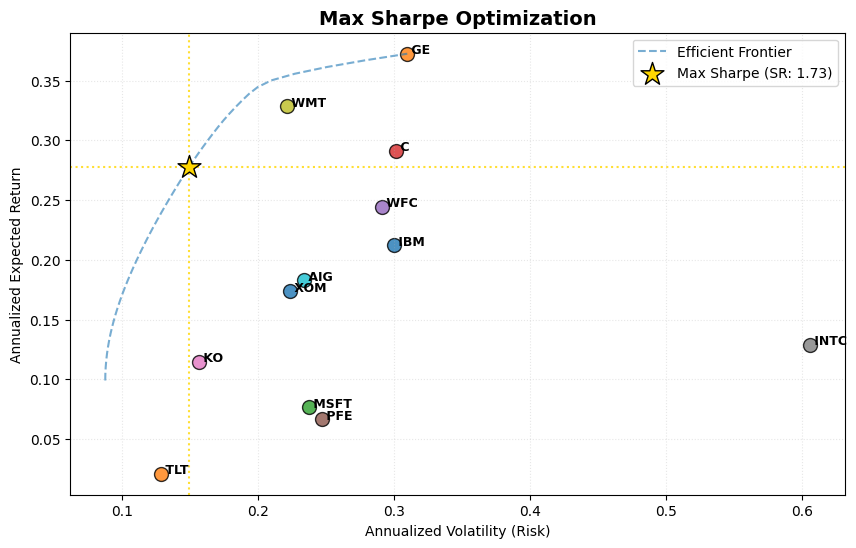

In [13]:
fig, weights = plot_efficient_frontier(bl_df, cv, basket, find_max_sharpe = True)
plt.show()


In [14]:
weights


XOM     1.506735e-01
GE      1.908198e-01
MSFT    9.534363e-18
C       5.199572e-02
WFC     1.226777e-02
PFE     4.282234e-18
KO      1.259353e-01
INTC    2.913008e-16
WMT     4.195674e-01
AIG     6.199294e-03
IBM     4.254117e-02
TLT     0.000000e+00
Name: Optimal weights, dtype: float64

In [15]:
price_data = get_full_portfolio_df(basket, start_date = start_date)




Fetching data for XOM...
Fetching data for GE...
Fetching data for MSFT...
Fetching data for C...
Fetching data for WFC...
Fetching data for PFE...
Fetching data for KO...
Fetching data for INTC...
Fetching data for WMT...
Fetching data for AIG...
Fetching data for IBM...
Fetching data for TLT...


In [16]:
cleaned_hrp = run_hrp_optimization(price_data)
hrp_ret, hrp_vol, hrp_sharpe = get_returns(cleaned_hrp, price_data, stats, cv)
print(f"HRP Sharpe Ratio: {hrp_sharpe:.2f}")


HRP Sharpe Ratio: 0.87


In [17]:
cleaned_cvar = run_cvar_optimization(price_data)
cvar_ret, cvar_vol, cvar_sharpe = get_returns(cleaned_cvar, price_data, stats, cv)
print(f"CVAR Sharpe Ratio: {cvar_sharpe:.2f}\nCVAR Ret: {cvar_ret:.2f}\nCVAR Vol: {cvar_vol:.2f}")


CVAR Sharpe Ratio: 1.34
CVAR Ret: 0.15
CVAR Vol: 0.10


In [18]:
print(f"CVAR Sharpe Ratio: {cvar_sharpe:.2f}\nCVAR Ret: {cvar_ret:.2f}\nCVAR Vol: {cvar_vol:.2f}")
print(f"HRP Sharpe Ratio: {hrp_sharpe:.2f}\nHRP Ret: {hrp_ret:.2f}\nHRP Vol: {hrp_vol:.2f}")


CVAR Sharpe Ratio: 1.34
CVAR Ret: 0.15
CVAR Vol: 0.10
HRP Sharpe Ratio: 0.87
HRP Ret: 0.10
HRP Vol: 0.09


In [19]:
from helper import run_10yr_backtest, run_mpt_optimization, extract_portfolio_metrics, calculate_average_turnover


In [20]:
def run_spy_benchmark(price_data, start_idx=252):
    """
    Simulates a $100 investment in SPY starting from the 
    first rebalance date of the other models.
    """
    # 1. Isolate SPY returns
    spy_returns = price_data['SPY'].pct_change().dropna()
    
    # 2. Align the start date with your other backtests (after the 1yr lookback)
    spy_test_returns = spy_returns.iloc[start_idx:]
    
    # 3. Calculate the cumulative growth of $100
    spy_equity_curve = 100 * (1 + spy_test_returns).cumprod()
    
    return spy_equity_curve


In [21]:
back_price_data = get_full_portfolio_df(basket, start_date = "2005-01-01")
mpt_sharpe_ec, mpt_sharpe_weights = run_10yr_backtest(back_price_data, lambda data: run_mpt_optimization(data, find_max_sharpe = True), rebalance_days = 30, lookback_days = 100)
mpt_vol_ec, mpt_vol_weights = run_10yr_backtest(back_price_data, lambda data: run_mpt_optimization(data, target_vol = 0.1), rebalance_days = 30, lookback_days = 100)
hrp_ec, hrp_weights = run_10yr_backtest(back_price_data, run_hrp_optimization, rebalance_days = 30, lookback_days = 100)
cvar_ec, cvar_weights = run_10yr_backtest(back_price_data, lambda data: run_cvar_optimization(data, alpha = 0.95), rebalance_days = 30, lookback_days = 100)
spy_ec = run_spy_benchmark(get_full_portfolio_df(["SPY"], start_date = "2005-01-01"))


Fetching data for XOM...
Fetching data for GE...
Fetching data for MSFT...
Fetching data for C...
Fetching data for WFC...
Fetching data for PFE...
Fetching data for KO...
Fetching data for INTC...
Fetching data for WMT...
Fetching data for AIG...
Fetching data for IBM...
Fetching data for TLT...
Fetching data for SPY...


In [22]:
mpt_sharpe_ec


2005-05-27 04:00:00    100.195508
2005-05-31 04:00:00    100.183263
2005-06-01 04:00:00    101.261320
2005-06-02 04:00:00    101.820370
2005-06-03 04:00:00    100.997772
                          ...    
2024-11-06 05:00:00    348.026933
2024-11-07 05:00:00    348.858308
2024-11-08 05:00:00    351.373542
2024-11-11 05:00:00    350.469351
2024-11-12 05:00:00    349.667650
Length: 4736, dtype: float64

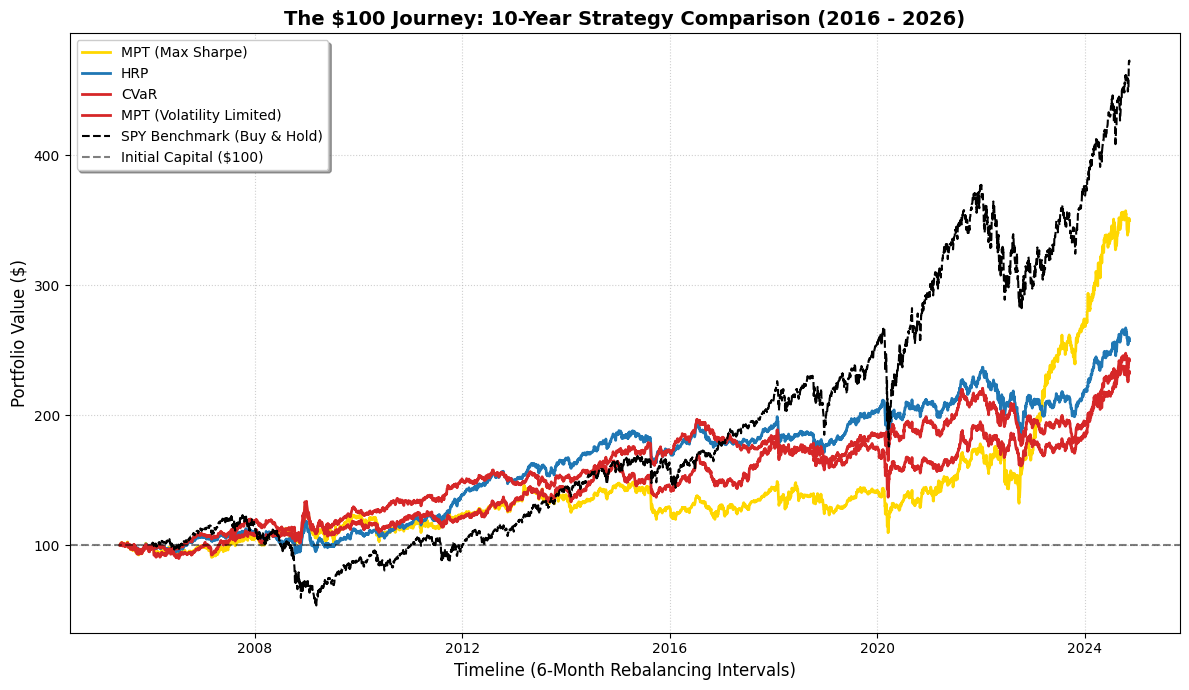

In [ ]:
plt.figure(figsize=(12, 7))
    
plt.plot(mpt_sharpe_ec, label="MPT (Max Sharpe)", color='#FFD700', linewidth=2) # Gold
plt.plot(hrp_ec, label="HRP", color='#1f77b4', linewidth=2) # Blue
plt.plot(cvar_ec, label="CVaR", color='#d62728', linewidth=2) # Red
plt.plot(mpt_vol_ec, label="MPT (Volatility Limited)", color='#d62728', linewidth=2) # Red

plt.plot(spy_ec, label="SPY Benchmark (Buy & Hold)", color='black', linestyle='--', linewidth=1.5)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5, label="Initial Capital ($100)")


plt.title("The $100 Journey: 10-Year Strategy Comparison (2016 - 2026)", fontsize=14, fontweight='bold')
plt.xlabel("Timeline (6-Month Rebalancing Intervals)", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)


plt.tight_layout()
plt.show()


In [24]:
extract_portfolio_metrics(mpt_sharpe_ec)


{'CAGR': '6.63%',
 'Volatility': '15.51%',
 'Sharpe Ratio': np.float64(0.3),
 'Max Drawdown': '-26.40%'}

In [25]:
extract_portfolio_metrics(mpt_vol_ec)


{'CAGR': '4.64%',
 'Volatility': '12.04%',
 'Sharpe Ratio': np.float64(0.22),
 'Max Drawdown': '-27.42%'}

In [26]:
extract_portfolio_metrics(hrp_ec)


{'CAGR': '4.97%',
 'Volatility': '10.08%',
 'Sharpe Ratio': np.float64(0.3),
 'Max Drawdown': '-21.88%'}

In [27]:
extract_portfolio_metrics(cvar_ec)


{'CAGR': '4.42%',
 'Volatility': '9.69%',
 'Sharpe Ratio': np.float64(0.25),
 'Max Drawdown': '-19.97%'}

In [28]:
extract_portfolio_metrics(spy_ec)


{'CAGR': '8.54%',
 'Volatility': '19.46%',
 'Sharpe Ratio': np.float64(0.34),
 'Max Drawdown': '-56.47%'}

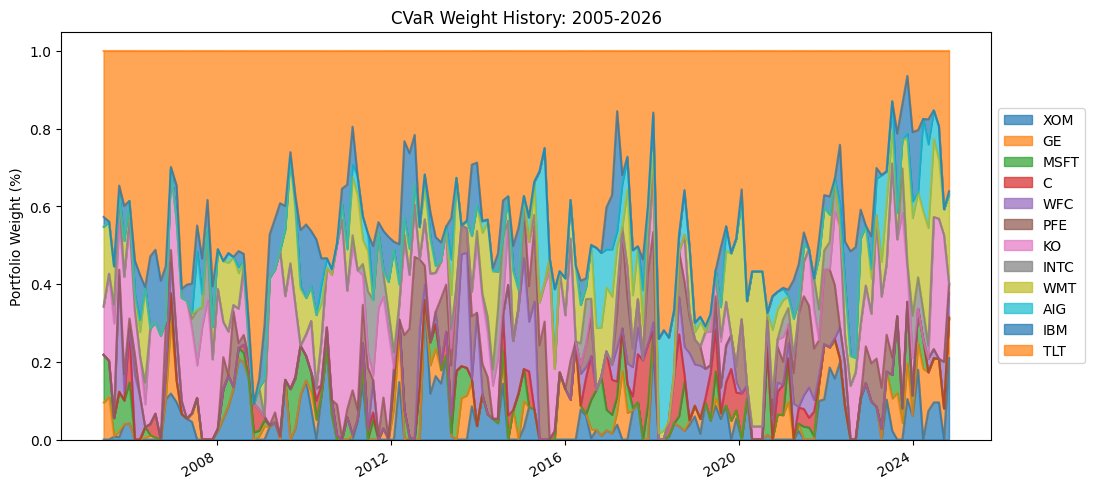

In [29]:
cvar_weights.plot(kind='area', stacked=True, alpha=0.7, figsize=(12, 6))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Portfolio Weight (%)")
plt.title("CVaR Weight History: 2005-2026")
plt.show()


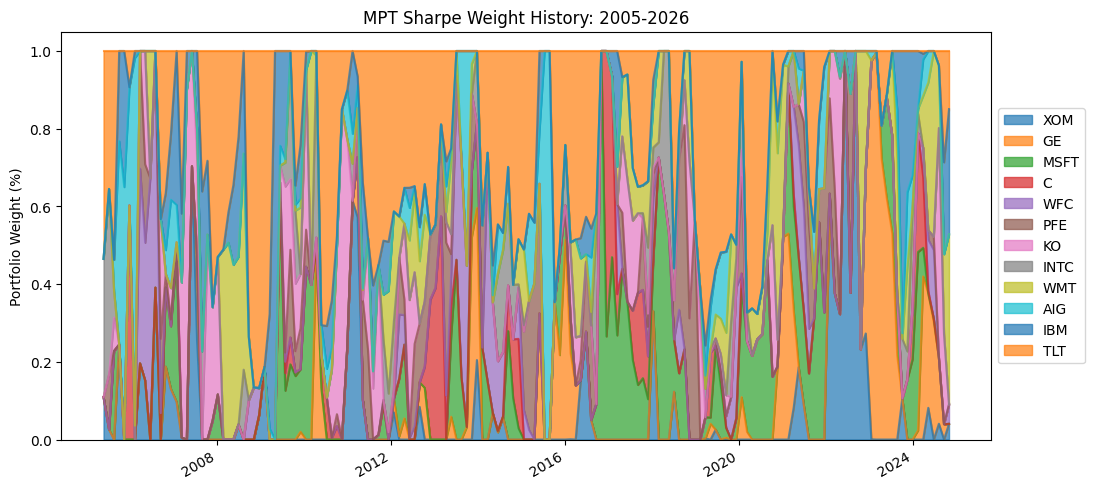

In [30]:
mpt_sharpe_weights.plot(kind='area', stacked=True, alpha=0.7, figsize=(12, 6))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Portfolio Weight (%)")
plt.title("MPT Sharpe Weight History: 2005-2026")
plt.show()


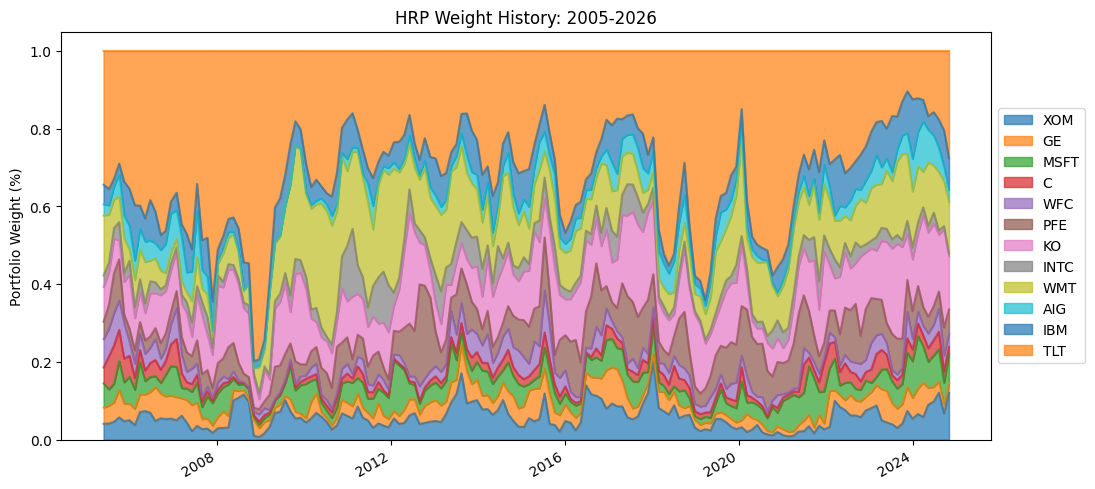

In [31]:
hrp_weights.plot(kind='area', stacked=True, alpha=0.7, figsize=(12, 6))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Portfolio Weight (%)")
plt.title("HRP Weight History: 2005-2026")
plt.show()


In [32]:
# Example usage for your four strategies:
mpt_sharpe_turnover = calculate_average_turnover(mpt_sharpe_weights)
mpt_vol_turnover = calculate_average_turnover(mpt_vol_weights)
hrp_turnover = calculate_average_turnover(hrp_weights)
cvar_turnover = calculate_average_turnover(cvar_weights)

print(f"MPT Sharpe Average Turnover: {mpt_sharpe_turnover:.2%}")
print(f"MPT Vol Average Turnover: {mpt_vol_turnover:.2%}")
print(f"HRP Average Turnover: {hrp_turnover:.2%}")
print(f"CVaR Average Turnover: {cvar_turnover:.2%}")


MPT Sharpe Average Turnover: 43.64%
MPT Vol Average Turnover: 36.94%
HRP Average Turnover: 12.62%
CVaR Average Turnover: 27.16%
